# Cross-Entropy & KL Divergence — a step-by-step, runnable teaching notebook

This notebook builds cross-entropy and KL divergence from the ground up on **real data**, one operation at a time. It is the executable companion to the chapter and to `cross_entropy_kl.py` — every function used here lives in that module, imported so the notebook and the module can never drift apart.

By the end you will have **measured**, on real corpora and real datasets:

1. **Entropy as expected surprise** — the letter distribution of a real corpus is ~4.19 bits/letter;
2. the **binary-entropy curve**, peaking at exactly 1 bit for a fair coin;
3. **cross-entropy** $H(p,q)=-\sum p\log q$ and its decomposition $H(p,q)=H(p)+D_{KL}(p\|q)$;
4. **KL $\ge 0$** (Gibbs) and its **asymmetry** $D_{KL}(p\|q)\ne D_{KL}(q\|p)$, both measured;
5. **cross-entropy IS the classification loss** — a real softmax classifier trained by GD, its loss falling from $\ln 10$, matched to `sklearn.log_loss`, with the **$(p-y)$ gradient** verified;
6. **forward vs reverse KL** — fitting one Gaussian to a real bimodal distribution (cover vs seek);
7. **perplexity** $= 2^{H}$ of real n-gram language models on real held-out text;
8. the **Gaussian KL** closed form, cross-checked against a numeric integral.

Everything runs on CPU in a few seconds, seeded for reproducibility. The first run downloads the 20-newsgroups corpus once into scikit-learn's cache; after that it is fully offline.

## Step 0 — Setup and version banner

We import the real functions from the chapter module (so this notebook uses the *exact same code* the figures and the page use) and print the library versions the results were produced on.

In [1]:
import numpy as np
import scipy
import sklearn
import matplotlib
import matplotlib.pyplot as plt

from cross_entropy_kl import (
    shannon_entropy_bits, binary_entropy_bits, letter_distribution,
    cross_entropy_bits, kl_divergence_bits, compare_distributions,
    softmax, train_softmax_gd, load_digits_split, standardize,
    real_bimodal_scores, mode_centers, fit_gaussian_forward_kl, fit_gaussian_reverse_kl,
    build_lm_corpus, unigram_perplexity, bigram_perplexity,
    kl_two_gaussians, kl_two_gaussians_numeric, N_CLASSES, RNG_SEED,
)
from sklearn.datasets import fetch_20newsgroups
from sklearn.metrics import log_loss

print(f'numpy {np.__version__} | scipy {scipy.__version__} | scikit-learn {sklearn.__version__} '
      f'| matplotlib {matplotlib.__version__}')
rng = np.random.default_rng(RNG_SEED)
REMOVE = ('headers', 'footers', 'quotes')

numpy 2.4.6 | scipy 1.17.1 | scikit-learn 1.9.0 | matplotlib 3.10.9


## Step 1 — Entropy is *expected surprise*, measured in bits

Before cross-entropy or KL, we need entropy. The **surprise** of seeing a symbol of probability $p$ is $-\log_2 p$ bits: a certain event ($p=1$) surprises you 0 bits; a one-in-a-million event surprises you ~20 bits. **Entropy** is the *average* surprise, $H(p)=-\sum_i p_i\log_2 p_i$ — and, by Shannon's source-coding theorem, the minimum average bits/symbol any lossless code can achieve.

Let's measure it on a **real corpus**: the letter frequencies of the `sci.space` newsgroup. The answer (~4.19 bits/letter) is the classic figure for English text — well below the 4.70 bits a uniform 26-letter alphabet would need, because real letters are far from uniform.

In [2]:
space = fetch_20newsgroups(subset='train', categories=['sci.space'], remove=REMOVE)
letters, p_letters = letter_distribution(' '.join(space.data))

H = shannon_entropy_bits(p_letters)
print(f'corpus: {len(space.data)} documents, {len(letters)} distinct letters')
print(f'H(letters) = {H:.4f} bits/letter   (English is famously ~4.1-4.2)')
print(f'uniform max = log2(26) = {np.log2(26):.4f} bits')
print(f'so real text saves {np.log2(26) - H:.3f} bits/letter over a uniform code')

# the three most and least surprising letters
surprise = -np.log2(p_letters)
order = np.argsort(p_letters)[::-1]
print('\nmost frequent (least surprising):', [letters[i] for i in order[:5]])
print('least frequent (most surprising):', [letters[i] for i in order[-5:]])

corpus: 593 documents, 26 distinct letters
H(letters) = 4.1852 bits/letter   (English is famously ~4.1-4.2)
uniform max = log2(26) = 4.7004 bits
so real text saves 0.515 bits/letter over a uniform code

most frequent (least surprising): ['e', 't', 'a', 'o', 'i']
least frequent (most surprising): ['k', 'x', 'j', 'q', 'z']


## Step 2 — The binary-entropy curve: uncertainty of a coin

The simplest entropy is a single yes/no outcome with probability $p$: $H(p) = -p\log_2 p - (1-p)\log_2(1-p)$. It is **0** at $p=0$ or $p=1$ (a certain coin — no surprise) and **maximal, exactly 1 bit, at $p=0.5$** (a fair coin — you truly can't predict it). This curve is the shape of every binary cross-entropy loss you'll ever train.

H(0.5) = 1.0 bit (max)
H(0.1) = 0.469 bit
H(0.01)= 0.0808 bit


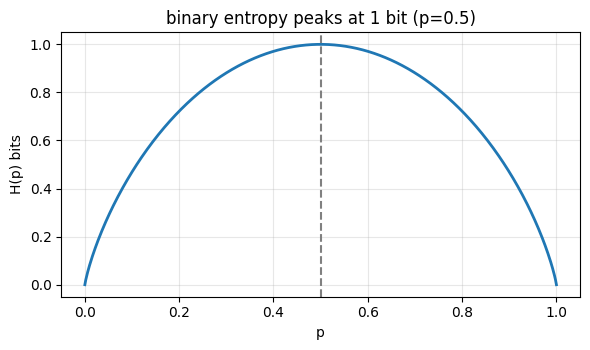

In [3]:
grid = np.linspace(1e-6, 1 - 1e-6, 500)
Hb = binary_entropy_bits(grid)
print('H(0.5) =', round(binary_entropy_bits(np.array([0.5]))[0], 4), 'bit (max)')
print('H(0.1) =', round(binary_entropy_bits(np.array([0.1]))[0], 4), 'bit')
print('H(0.01)=', round(binary_entropy_bits(np.array([0.01]))[0], 4), 'bit')

plt.figure(figsize=(6, 3.6))
plt.plot(grid, Hb, lw=2)
plt.axvline(0.5, ls='--', color='gray')
plt.xlabel('p')
plt.ylabel('H(p) bits')
plt.title('binary entropy peaks at 1 bit (p=0.5)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Step 3 — Cross-entropy: the cost of coding $p$ with the *wrong* model $q$

Now bring in a second distribution. If the truth is $p$ but you build your code assuming $q$, each symbol costs $-\log_2 q_i$ bits and you pay $p_i$ of them on average:

$$H(p,q) = -\sum_i p_i \log_2 q_i.$$

Two real distributions to compare: the letter frequencies of `sci.space` ($p$) and of `rec.sport.baseball` ($q$). Cross-entropy is minimised, over all $q$, exactly when $q=p$ — at which point it equals the entropy $H(p)$. So $H(p,q)\ge H(p)$ always, with the *gap* being the KL divergence of the next step.

In [4]:
baseball = fetch_20newsgroups(subset='train', categories=['rec.sport.baseball'], remove=REMOVE)
_, q_letters = letter_distribution(' '.join(baseball.data))

H_p  = shannon_entropy_bits(p_letters)
H_pq = cross_entropy_bits(p_letters, q_letters)
H_pp = cross_entropy_bits(p_letters, p_letters)   # coding p with p == entropy of p
print(f'H(p)        = {H_p:.4f} bits   (entropy of sci.space letters)')
print(f'H(p, p)     = {H_pp:.4f} bits   (== H(p): the best possible)')
print(f'H(p, q)     = {H_pq:.4f} bits   (coding sci.space letters with the baseball model)')
print(f'gap H(p,q) - H(p) = {H_pq - H_p:.4f} bits  <- this is exactly D_KL(p||q)')

H(p)        = 4.1852 bits   (entropy of sci.space letters)
H(p, p)     = 4.1852 bits   (== H(p): the best possible)
H(p, q)     = 4.1989 bits   (coding sci.space letters with the baseball model)
gap H(p,q) - H(p) = 0.0137 bits  <- this is exactly D_KL(p||q)


## Step 4 — KL divergence: the *extra* bits, and $H(p,q)=H(p)+D_{KL}(p\|q)$

The gap you just saw has a name: the **Kullback–Leibler divergence**

$$D_{KL}(p\|q) = \sum_i p_i \log_2 \frac{p_i}{q_i} = H(p,q) - H(p).$$

It is the number of **wasted** bits per symbol from using model $q$ when the truth is $p$. We verify the decomposition $H(p,q) = H(p) + D_{KL}(p\|q)$ numerically — it holds to machine precision because it is an identity, not an approximation.

In [5]:
cmp = compare_distributions(p_letters, q_letters)
print(f'H(p)              = {cmp.h_p:.4f} bits')
print(f'D_KL(p||q)        = {cmp.kl_pq:.4f} bits   (the extra/wasted bits)')
print(f'H(p) + D_KL(p||q) = {cmp.h_p + cmp.kl_pq:.4f} bits')
print(f'H(p, q)           = {cmp.h_pq:.4f} bits')
print('identity H(p,q) == H(p)+D_KL(p||q):', cmp.identity_holds)

H(p)              = 4.1852 bits
D_KL(p||q)        = 0.0137 bits   (the extra/wasted bits)
H(p) + D_KL(p||q) = 4.1989 bits
H(p, q)           = 4.1989 bits
identity H(p,q) == H(p)+D_KL(p||q): True


## Step 5 — KL is $\ge 0$ (Gibbs) and **asymmetric** (a divergence, not a distance)

Two properties that trip people up, both *measured* here:

* **Non-negativity** ($D_{KL}\ge 0$, zero iff $p=q$) — *Gibbs' inequality*, a consequence of the concavity of $\log$ (Jensen). You can never do better than coding $p$ with $p$ itself.
* **Asymmetry** — $D_{KL}(p\|q)\ne D_{KL}(q\|p)$ in general. This is *the* reason KL is a *divergence*, not a *distance*: it has no symmetry and no triangle inequality.

The two real corpora are so similar that their asymmetry is tiny, so we also show a clean, large asymmetry: real letters vs a **uniform** model. There, $D_{KL}(\text{real}\|\text{uniform}) = \log_2 26 - H(p)$ exactly — a lovely closed form.

In [6]:
print(f'D_KL(p||q) = {cmp.kl_pq:.5f} bits')
print(f'D_KL(q||p) = {cmp.kl_qp:.5f} bits   (different -> asymmetric)')
print(f'D_KL(p||p) = {kl_divergence_bits(p_letters, p_letters):.5f} bits   (zero: q==p)')
print('both KL >= 0:', cmp.kl_pq >= 0 and cmp.kl_qp >= 0, '(Gibbs)')

uniform = np.full_like(p_letters, 1.0 / p_letters.size)
kl_pu = kl_divergence_bits(p_letters, uniform)
kl_up = kl_divergence_bits(uniform, p_letters)
print(f'\nD_KL(real||uniform) = {kl_pu:.4f} bits')
print(f'D_KL(uniform||real) = {kl_up:.4f} bits   ({kl_up/kl_pu:.2f}x larger -> asymmetric)')
print(f'check: log2(26) - H(p) = {np.log2(26) - cmp.h_p:.4f}  == D_KL(real||uniform)')

D_KL(p||q) = 0.01366 bits
D_KL(q||p) = 0.01386 bits   (different -> asymmetric)
D_KL(p||p) = 0.00000 bits   (zero: q==p)
both KL >= 0: True (Gibbs)

D_KL(real||uniform) = 0.5152 bits
D_KL(uniform||real) = 0.8119 bits   (1.58x larger -> asymmetric)
check: log2(26) - H(p) = 0.5152  == D_KL(real||uniform)


## Step 6 — Cross-entropy IS the classification loss (real digits)

Here is why this topic dominates ML. When you train a classifier, the loss you minimise **is** the cross-entropy between the one-hot true labels and the predicted probabilities. For a single example with true class $c$, that cross-entropy collapses to the **negative log-likelihood** of the truth:

$$H(\text{one-hot}, \hat p) = -\sum_k \mathbb{1}[k=c]\log \hat p_k = -\log \hat p_c.$$

NLL == cross-entropy == $-\log p(\text{true class})$. We load the real 8×8 `load_digits` dataset and standardise it, ready to train a softmax classifier and watch its cross-entropy fall.

In [7]:
x_tr, x_te, y_tr, y_te = load_digits_split()
x_tr_s, x_te_s = standardize(x_tr, x_te)
print('train:', x_tr_s.shape, '| test:', x_te_s.shape, '| classes:', N_CLASSES)
print('a uniform guess has loss ln(10) =', round(np.log(10), 4), 'nats (the starting floor)')

train: (1257, 64) | test: (540, 64) | classes: 10
a uniform guess has loss ln(10) = 2.3026 nats (the starting floor)


## Step 7 — Train it by gradient descent and watch cross-entropy fall

We train a softmax (multinomial logistic) classifier by full-batch gradient descent, recording the cross-entropy at every step. It starts at $\ln 10 \approx 2.30$ (a uniform guess over 10 classes) and falls as the model learns. At the end we confirm our hand-computed cross-entropy equals `sklearn.metrics.log_loss` to 6 decimals — it is literally the same quantity.

CE at step 0   = 2.3026  (= ln 10 = 2.3026)
CE at step 300 = 0.0643  (converged)

our cross-entropy        = 0.064163
sklearn.metrics.log_loss = 0.064163
they match: True


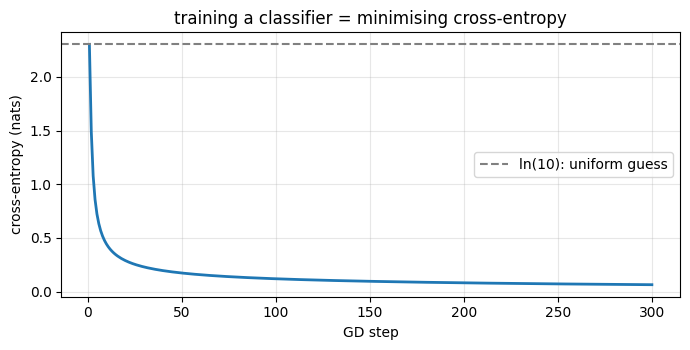

In [8]:
trained = train_softmax_gd(x_tr_s, y_tr)
curve = trained.loss_curve
print(f'CE at step 0   = {curve[0]:.4f}  (= ln 10 = {np.log(10):.4f})')
print(f'CE at step {curve.size} = {curve[-1]:.4f}  (converged)')

n = x_tr_s.shape[0]
our_ce = -np.mean(np.log(trained.probs_train[np.arange(n), y_tr]))
sk_ce  = log_loss(y_tr, trained.probs_train)
print(f'\nour cross-entropy        = {our_ce:.6f}')
print(f'sklearn.metrics.log_loss = {sk_ce:.6f}')
print('they match:', bool(np.isclose(our_ce, sk_ce, atol=1e-6)))

plt.figure(figsize=(7, 3.6))
plt.plot(range(1, curve.size + 1), curve, lw=2)
plt.axhline(np.log(10), ls='--', color='gray', label='ln(10): uniform guess')
plt.xlabel('GD step')
plt.ylabel('cross-entropy (nats)')
plt.title('training a classifier = minimising cross-entropy')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Step 8 — NLL of a single example, and the famous $(p-y)$ gradient

Two things worth seeing directly. First, the loss for one example really is just $-\log$ of the probability it assigned the true class. Second — the reason softmax + cross-entropy is *the* pairing — the gradient of the loss with respect to the **logits** simplifies to the beautifully clean

$$\frac{\partial \mathcal{L}}{\partial z} = \hat p - y \quad(\text{predicted} - \text{one-hot true}).$$

No division, no softmax derivative left over — the messy Jacobian cancels the $1/\hat p$ from the log. We verify it against a finite-difference gradient on a real example.

In [9]:
i = 0
true_c = y_tr[i]
p_i = trained.probs_train[i]
print(f'example {i}: true class = {true_c}, p(true) = {p_i[true_c]:.4f}')
print(f'NLL = -log p(true) = {-np.log(p_i[true_c]):.4f}   (== its cross-entropy)')

# verify d L_i / d logits == (p - y) by finite differences, on one example's logits
W, b = trained.weights, trained.bias
z = x_tr_s[i] @ W + b
y_onehot = np.eye(N_CLASSES)[true_c]
analytic = softmax(z[None])[0] - y_onehot          # the (p - y) claim
eps = 1e-6
numeric = np.zeros(N_CLASSES)
for k in range(N_CLASSES):
    zp = z.copy()
    zp[k] += eps
    zm = z.copy()
    zm[k] -= eps
    Lp = -np.log(softmax(zp[None])[0][true_c])
    Lm = -np.log(softmax(zm[None])[0][true_c])
    numeric[k] = (Lp - Lm) / (2 * eps)
print('\nanalytic (p - y):', np.round(analytic, 4))
print('finite-difference:', np.round(numeric, 4))
print('match:', bool(np.allclose(analytic, numeric, atol=1e-5)))

example 0: true class = 6, p(true) = 0.9765
NLL = -log p(true) = 0.0238   (== its cross-entropy)

analytic (p - y): [ 0.0002  0.0142  0.0002  0.      0.0083  0.0001 -0.0235  0.0002  0.0002
  0.    ]
finite-difference: [ 0.0002  0.0142  0.0002  0.      0.0083  0.0001 -0.0235  0.0002  0.0002
  0.    ]
match: True


## Step 9 — The same loss under `sklearn.LogisticRegression`

`LogisticRegression` with the multinomial option minimises exactly this cross-entropy (it calls it 'log loss'). We fit it on the same real data and report its held-out log-loss and accuracy — the cross-entropy on data the model never saw, the number you actually care about.

In [10]:
from sklearn.linear_model import LogisticRegression
clf = LogisticRegression(max_iter=2000, C=10.0).fit(x_tr_s, y_tr)
test_ce = log_loss(y_te, clf.predict_proba(x_te_s))
print(f'held-out cross-entropy (log-loss): {test_ce:.4f} nats')
print(f'held-out accuracy                : {clf.score(x_te_s, y_te):.4f}')
print('lower cross-entropy => better-calibrated probabilities, not just correct labels')

held-out cross-entropy (log-loss): 0.1123 nats
held-out accuracy                : 0.9630
lower cross-entropy => better-calibrated probabilities, not just correct labels


## Step 10 — Forward vs reverse KL: fitting one Gaussian to a *real bimodal* distribution

KL's asymmetry has teeth. Suppose your data $p$ has **two modes** but your model $q$ is a single Gaussian — it *cannot* match $p$. Which way you write the KL decides how it fails:

* **Forward** $\arg\min_q D_{KL}(p\|q)$ (this is MLE) is **mode-covering**: it is penalised wherever $p>0$ but $q\approx 0$, so it stretches to cover *both* modes (a wide Gaussian = moment matching).
* **Reverse** $\arg\min_q D_{KL}(q\|p)$ (this is variational inference / the ELBO) is **mode-seeking**: it is penalised wherever $q>0$ but $p\approx 0$, so it collapses onto *one* mode (a narrow spike).

The real bimodal data: PC1 scores of two visually distinct digit classes (0 and 6), which separate into two bumps.

real modes at PC1 = -0.959 and 0.943  (two bumps)
forward KL fit: mu=-0.000, sigma=1.000  -> mode-COVERING (wide, spans both)
reverse KL fit: mu=-1.024, sigma=0.068  -> mode-SEEKING (narrow, one mode)
reverse fit is narrower: True


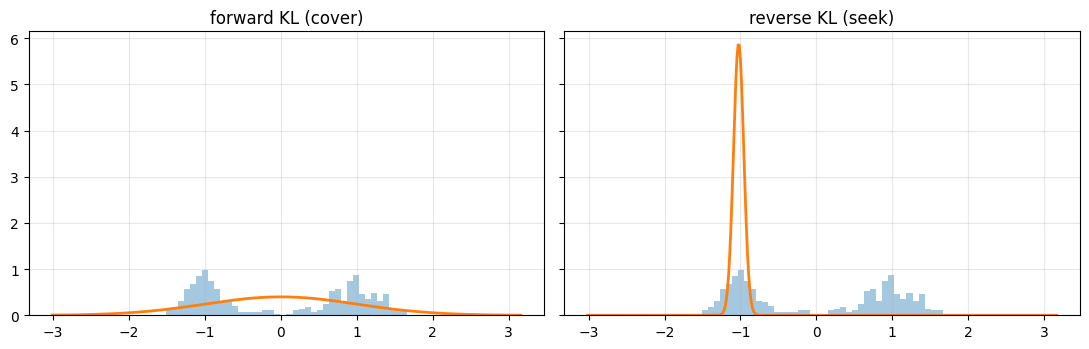

In [11]:
scores = real_bimodal_scores()
grid = np.linspace(scores.min() - 1.5, scores.max() + 1.5, 500)
centers = 0.5 * (grid[:-1] + grid[1:])
m0, m1 = mode_centers()
print(f'real modes at PC1 = {m0:.3f} and {m1:.3f}  (two bumps)')

fwd = fit_gaussian_forward_kl(scores, grid, centers)
rev = fit_gaussian_reverse_kl(scores, grid, centers, mode_inits=(m0, m1))
print(f'forward KL fit: mu={fwd.mu:+.3f}, sigma={fwd.sigma:.3f}  -> mode-COVERING (wide, spans both)')
print(f'reverse KL fit: mu={rev.mu:+.3f}, sigma={rev.sigma:.3f}  -> mode-SEEKING (narrow, one mode)')
print('reverse fit is narrower:', rev.sigma < fwd.sigma)

xs = np.linspace(scores.min() - 1.5, scores.max() + 1.5, 400)

def gauss(mu, s):
    return np.exp(-0.5 * ((xs - mu) / s) ** 2) / (s * np.sqrt(2 * np.pi))

fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 3.6), sharey=True)
for ax, fit, ttl in ((a1, fwd, 'forward KL (cover)'), (a2, rev, 'reverse KL (seek)')):
    ax.hist(scores, bins=40, density=True, alpha=0.4)
    ax.plot(xs, gauss(fit.mu, fit.sigma), lw=2)
    ax.set_title(ttl)
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Step 11 — Why forward KL = maximum likelihood

The forward-KL fit above was just the data's mean and variance — *moment matching*. That is no accident. Minimising $D_{KL}(\hat p_{\text{data}}\|q_\theta)$ over the model $q_\theta$ is identical to **maximising the log-likelihood** of the data, because

$$D_{KL}(\hat p\|q_\theta) = \underbrace{\sum_x \hat p(x)\log \hat p(x)}_{-H(\hat p),\ \text{const in }\theta} - \underbrace{\sum_x \hat p(x)\log q_\theta(x)}_{\frac{1}{N}\sum_i \log q_\theta(x_i)}.$$

The first term doesn't depend on $\theta$, so minimising KL = maximising the average log-likelihood = minimising cross-entropy. We show it numerically: the forward-KL Gaussian's parameters equal the closed-form MLE (sample mean and std).

In [12]:
mle_mu, mle_sigma = scores.mean(), scores.std()
print(f'MLE (sample mean, std)   : mu={mle_mu:+.4f}, sigma={mle_sigma:.4f}')
print(f'forward-KL fit           : mu={fwd.mu:+.4f}, sigma={fwd.sigma:.4f}')
print('identical:', bool(np.isclose(mle_mu, fwd.mu) and np.isclose(mle_sigma, fwd.sigma)))
print('\n=> minimising forward KL to the data == maximising likelihood == minimising cross-entropy')

MLE (sample mean, std)   : mu=-0.0000, sigma=1.0000
forward-KL fit           : mu=-0.0000, sigma=1.0000
identical: True

=> minimising forward KL to the data == maximising likelihood == minimising cross-entropy


## Step 12 — Perplexity: cross-entropy for language models

Language models report **perplexity**, which is just cross-entropy in disguise:

$$\text{perplexity} = 2^{H} = 2^{-\frac{1}{N}\sum_i \log_2 q(w_i\mid\text{context})}.$$

It is the model's *effective branching factor* — how many equally-likely words it is choosing among at each step. Lower is better. We build two real n-gram models on real held-out newsgroup text — a context-free **unigram** and an interpolated **bigram** — and watch context lower the perplexity.

In [13]:
train, test, vocab_size = build_lm_corpus()
uni = unigram_perplexity(train, test, vocab_size)
bi  = bigram_perplexity(train, test, vocab_size)
print(f'corpus: {len(train):,} train tokens, {len(test):,} held-out, vocab {vocab_size:,}')
print(f'{uni.name:<22}: {uni.bits_per_word:.4f} bits/word -> perplexity {uni.perplexity:.1f}')
print(f'{bi.name:<22}: {bi.bits_per_word:.4f} bits/word -> perplexity {bi.perplexity:.1f}')
print(f'the bigram is {uni.perplexity/bi.perplexity:.2f}x less perplexed (context helps)')

corpus: 360,467 train tokens, 40,052 held-out, vocab 5,001
unigram               : 9.2068 bits/word -> perplexity 590.9
bigram (interpolated) : 8.3345 bits/word -> perplexity 322.8
the bigram is 1.83x less perplexed (context helps)


## Step 13 — The Gaussian KL closed form (the VAE regulariser)

For two Gaussians the KL has a clean closed form — the only reason variational autoencoders can put a KL term in their loss cheaply:

$$D_{KL}\big(\mathcal N(\mu_0,\sigma_0)\,\|\,\mathcal N(\mu_1,\sigma_1)\big) = \log\frac{\sigma_1}{\sigma_0} + \frac{\sigma_0^2 + (\mu_0-\mu_1)^2}{2\sigma_1^2} - \frac12.$$

We check the formula against a brute-force numeric integral — they agree to 3+ decimals, confirming the algebra.

In [14]:
closed  = kl_two_gaussians(0.0, 1.0, 1.5, 2.0)
numeric = kl_two_gaussians_numeric(0.0, 1.0, 1.5, 2.0)
print(f'D_KL(N(0,1) || N(1.5,2))  closed form = {closed:.5f} nats')
print(f'                          numeric int = {numeric:.5f} nats')
print('match:', bool(np.isclose(closed, numeric, atol=1e-3)))

# KL is 0 iff the Gaussians coincide, and grows as they drift apart
print('\nD_KL(N(0,1) || N(0,1))    =', round(kl_two_gaussians(0, 1, 0, 1), 6), '(identical -> 0)')
print('D_KL(N(0,1) || N(3,1))    =', round(kl_two_gaussians(0, 1, 3, 1), 4), '(far apart -> large)')

D_KL(N(0,1) || N(1.5,2))  closed form = 0.59940 nats
                          numeric int = 0.59940 nats
match: True

D_KL(N(0,1) || N(0,1))    = 0.0 (identical -> 0)
D_KL(N(0,1) || N(3,1))    = 4.5 (far apart -> large)


## Recap

In one runnable notebook, on real data, we established:

| Step | What we saw | The takeaway |
|---|---|---|
| 1–2 | real letter entropy ~4.19 bits; binary-entropy curve | entropy = expected surprise, in bits |
| 3–4 | $H(p,q)$ and $H(p,q)=H(p)+D_{KL}(p\|q)$ | cross-entropy = floor + KL 'waste' |
| 5 | $D_{KL}\ge 0$ and asymmetric | KL is a divergence, not a distance |
| 6–9 | softmax on digits, loss $\downarrow$, $(p-y)$, sklearn match | **cross-entropy IS the loss** |
| 10–11 | one Gaussian, two KLs; forward = MLE | cover vs seek; forward KL = max-likelihood |
| 12 | unigram vs bigram perplexity | perplexity $=2^{\text{cross-entropy}}$ |
| 13 | Gaussian KL closed form == numeric | the VAE regulariser, verified |

Every number here came from a real corpus or a real dataset and a real library call. That is the point: cross-entropy and KL are not abstractions to memorise — they are concrete, measurable quantities you can compute, see, and trust.